In [2]:
from __future__ import annotations

from os import PathLike
from typing import Any, Literal, Sequence
from types import EllipsisType

import numpy as np
from numpy.typing import DTypeLike

from pyflim.PTU.reader import PTUFile, PTUArray5D
from phasorpy.phasor import phasor_from_signal

In [3]:
def signal_from_PTUFile(
    filename: str | PathLike[Any],
    /,
    *,
    dtype: DTypeLike | None = None,
    frame: int | None = None,
    channel: int | None = 0,
    dtime: int | None = 0,
    binning: int = 1,
    keepdims: bool = False,
):
    """Return TCSPC histogram and metadata from a PTU T3 mode file.

    Uses pyflim's PTUFile / PTUArray5D for decoding instead of ptufile.

    Parameters
    ----------
    filename : str or Path
        Path to a PicoQuant PTU file.
    dtype : dtype_like, optional, default: uint16
        Unsigned integer type for the histogram array.
    frame : int, optional
        If < 0, integrate (sum) over the time/frame axis.
        If >= 0, select that single frame.
        If None, keep all frames.
    channel : int, optional, default: 0
        Detection channel index to return.
        If < 0, integrate (sum) over the channel axis.
        If None, keep all channels.
    dtime : int, optional, default: 0
        Number of histogram bins to keep.
        0  -> use all bins in one period (default).
        >0 -> keep the first *dtime* bins.
        <0 -> integrate (sum) over the histogram axis.
    binning : int, optional, default: 1
        Spatial binning factor applied when building the pixel stack.
    keepdims : bool, optional, default: False
        If True, reduced axes are kept as length-1 dimensions.

    Returns
    -------
    xarray.DataArray
        TCSPC histogram with axes ``'TYXCH'``.

        - ``coords['H']``: delay-time bin centres in nanoseconds.
        - ``attrs['frequency']``: laser repetition frequency in MHz.
        - ``attrs['ptu_tags']``: raw tag dictionary from the PTU header.
    """
    from xarray import DataArray

    ptu = PTUFile(str(filename), verbose=False)
    is_image = ptu.n_x > 0 and ptu.n_y > 0

    if is_image:
        arr5d = PTUArray5D(ptu, binning=binning)
        # arr5d.array has shape (T, Y, X, C, H)  dtype uint32
        data = arr5d.array.copy()
    else:
        # Point-mode: build (1, 1, 1, C, H) from summed decays per channel
        records = ptu._load_records()
        ch_raw, dtime_raw, _ = ptu._decode_picoharp_t3(records)
        active_chs = np.unique(ch_raw[ch_raw != 0xF])
        hists = []
        for c in active_chs:
            hists.append(ptu.summed_decay(channel=int(c)))
        # stack to (C, H), then expand to (T=1, Y=1, X=1, C, H)
        data = np.stack(hists, axis=0)[np.newaxis, np.newaxis, np.newaxis, :, :]

    # ---- dtype ----
    if dtype is None:
        dtype = np.uint16
    data = data.astype(dtype)

    n_bins_full = data.shape[-1]  # H axis length before any trimming

    # ---- dtime selection (H axis = -1) ----
    if dtime is not None:
        if dtime < 0:
            data = data.sum(axis=-1, keepdims=keepdims)
        elif dtime > 0:
            data = data[..., :dtime]
        # dtime == 0 → keep all bins (no-op)

    # ---- channel selection (C axis = 3) ----
    if channel is not None:
        if channel < 0:
            data = data.sum(axis=3, keepdims=keepdims)
        else:
            if keepdims:
                data = data[:, :, :, channel : channel + 1]
            else:
                data = data[:, :, :, channel]
            # after removing C, H was axis 4 → now axis 3

    # ---- frame selection (T axis = 0) ----
    if frame is not None:
        if frame < 0:
            data = data.sum(axis=0, keepdims=keepdims)
        else:
            if keepdims:
                data = data[frame : frame + 1]
            else:
                data = data[frame]

    # ---- Build dimension labels ----
    all_dims = ['T', 'Y', 'X', 'C', 'H']
    # Figure out which dims survived
    removed = []
    if dtime is not None and dtime < 0 and not keepdims:
        removed.append('H')
    if channel is not None and channel >= 0 and not keepdims:
        removed.append('C')
    if frame is not None and not keepdims:
        removed.append('T')
    dims = [d for d in all_dims if d not in removed]

    # ---- Build coordinates ----
    coords = {}
    h_bins = dtime if (dtime is not None and dtime > 0) else n_bins_full
    time_ns = ptu.time_ns[:h_bins]
    if 'H' in dims:
        coords['H'] = ('H', time_ns)

    # ---- Frequency in MHz ----
    frequency_mhz = ptu.sync_rate * 1e-6

    da = DataArray(
        data,
        dims=dims,
        coords=coords,
        attrs={
            'frequency': frequency_mhz,
            'ptu_tags': ptu.tags,
        },
    )
    return da

In [4]:
# Smoke test with a PTU file
signal = signal_from_PTUFile('TTTT.ptu')
print(f"shape:  {signal.shape}")
print(f"dims:   {signal.dims}")
print(f"dtype:  {signal.dtype}")
print(f"freq:   {signal.attrs['frequency']:.2f} MHz")
if 'H' in signal.coords:
    print(f"H range: {float(signal.coords['H'][0]):.2f} – {float(signal.coords['H'][-1]):.2f} ns")

shape:  (1, 1024, 1024, 529)
dims:   ('T', 'Y', 'X', 'H')
dtype:  uint16
freq:   19.50 MHz
H range: 0.05 – 51.25 ns


In [7]:
# H (histogram) is the last axis — tell phasor_from_signal to use it
mean, real, imag = phasor_from_signal(signal, axis='H')
print(f"phasor mean shape: {mean.shape}")
print(f"phasor mean min/max: {np.nanmin(mean):.2f} / {np.nanmax(mean):.2f}")
print(f"phasor real min/max: {np.nanmin(real):.4f} / {np.nanmax(real):.4f}")
print(f"phasor imag min/max: {np.nanmin(imag):.4f} / {np.nanmax(imag):.4f}")

phasor mean shape: (1, 1024, 1024)
phasor mean min/max: 0.00 / 0.03
phasor real min/max: -1.0000 / 1.0000
phasor imag min/max: -1.0000 / 1.0000


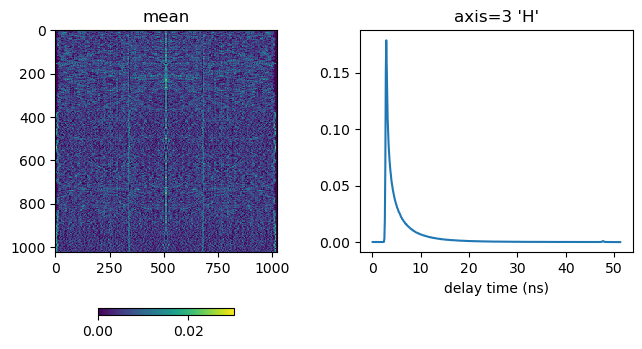

In [8]:
from phasorpy.plot import plot_signal_image

plot_signal_image(signal, axis='H', xlabel='delay time (ns)')

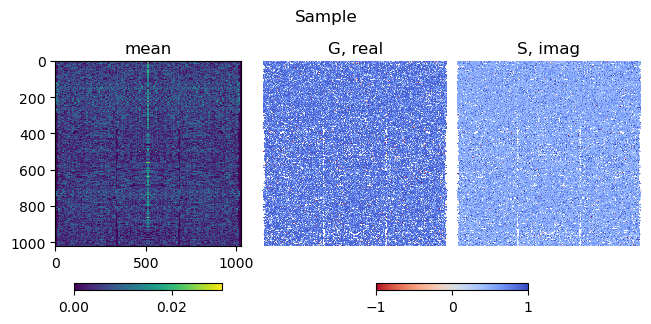

In [9]:
from phasorpy.plot import plot_phasor_image

plot_phasor_image(mean, real, imag, title='Sample')

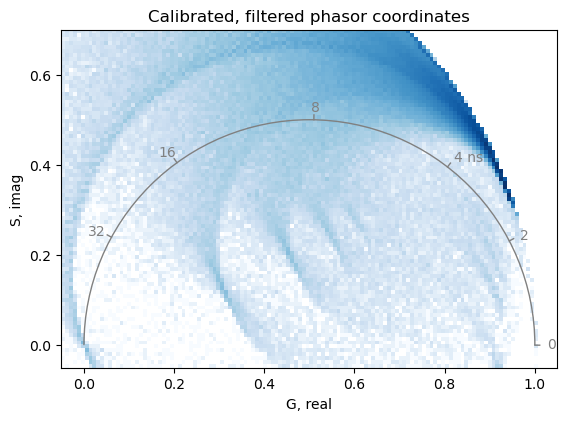

In [12]:
from phasorpy.plot import plot_phasor

frequency = signal.attrs['frequency']

plot_phasor(
    real,
    imag,
    frequency=frequency,
    title='Calibrated, filtered phasor coordinates',
)